In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter
import torch
import importlib
import scratch
importlib.reload(scratch)
from scratch import *

In [6]:
print("Loading MNIST data...")

train_dataset, test_dataset = load_mnist_data()

print("Preprocessing MNIST data...")

(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
) = preprocess_data(
    train_dataset,
    test_dataset,
    train_size=50000,
    test_size=10000,
    SPLIT_SEED=SPLIT_SEED
)

Loading MNIST data...
Preprocessing MNIST data...
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Original test images: (10000, 28, 28)
Original test labels: (10000,)
Splitting the training data into training and validation sets...
Training images: (50000, 28, 28)
Training labels: (50000,)
Validation images: (10000, 28, 28)
Validation labels: (10000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Before Normalization:
Training data range: 0.0 to 255.0
Validation data range: 0.0 to 255.0
Test data range: 0.0 to 255.0
Performing normalization of the data...
After Normalization:
Training data range: 0.0 to 1.0
Validation data range: 0.0 to 1.0
Test data range: 0.0 to 1.0


In [7]:


# ============================================================
# Final hyperparameter-search configuration
# ============================================================

FINAL_OUTPUT_DIR = Path(
    "output/test_reports"
)

FINAL_CHECKPOINT_DIR = (
    FINAL_OUTPUT_DIR / "checkpoints"
)

FINAL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Hyperparameters that will be searched
FINAL_LEARNING_RATES = [
    0.001,
    0.01,
    0.1
]

FINAL_INITIALIZATIONS = [
    "small",
    "he",
    "xavier",
    "large"
]


# Settings held constant
FINAL_HIDDEN_SIZE = 128
FINAL_ACTIVATION = "relu"
FINAL_BATCH_SIZE = 128
FINAL_EPOCHS = 100


# The same three seeds are used for every configuration
FINAL_SEEDS = generate_experiment_seeds(
    base_seed=SPLIT_SEED,
    number_of_seeds=3
)

FINAL_SEEDS = [
    int(seed)
    for seed in FINAL_SEEDS
]


FINAL_NUMBER_OF_CONFIGURATIONS = (
    len(FINAL_INITIALIZATIONS)
    * len(FINAL_LEARNING_RATES)
)

FINAL_NUMBER_OF_RUNS = (
    FINAL_NUMBER_OF_CONFIGURATIONS
    * len(FINAL_SEEDS)
)


print("Hyperparameter search configuration")
print("-----------------------------------")
print("Hidden layers: 1")
print("Hidden units:", FINAL_HIDDEN_SIZE)
print("Activation:", FINAL_ACTIVATION)
print("Batch size:", FINAL_BATCH_SIZE)
print("Maximum epochs:", FINAL_EPOCHS)
print("Initializations:", FINAL_INITIALIZATIONS)
print("Learning rates:", FINAL_LEARNING_RATES)
print("Seeds:", FINAL_SEEDS)
print(
    "Number of configurations:",
    FINAL_NUMBER_OF_CONFIGURATIONS
)
print(
    "Total training runs:",
    FINAL_NUMBER_OF_RUNS
)
print(
    "Checkpoint directory:",
    FINAL_CHECKPOINT_DIR
)

Hyperparameter search configuration
-----------------------------------
Hidden layers: 1
Hidden units: 128
Activation: relu
Batch size: 128
Maximum epochs: 100
Initializations: ['small', 'he', 'xavier', 'large']
Learning rates: [0.001, 0.01, 0.1]
Seeds: [654571, 89250, 773955]
Number of configurations: 12
Total training runs: 36
Checkpoint directory: output/test_reports/checkpoints


In [8]:
# ============================================================
# Train every initialization-learning-rate configuration
# ============================================================

final_grid_histories = {}
final_grid_validation_rows = []

final_run_number = 0


for initialization in FINAL_INITIALIZATIONS:

    for learning_rate in FINAL_LEARNING_RATES:

        configuration_label = (
            f"{initialization}, "
            f"lr={learning_rate:g}"
        )

        print("\n" + "=" * 80)
        print(
            "Configuration:",
            configuration_label
        )
        print("=" * 80)

        for seed in FINAL_SEEDS:

            final_run_number += 1

            print(
                f"\nRun {final_run_number}/"
                f"{FINAL_NUMBER_OF_RUNS} | "
                f"initialization={initialization} | "
                f"learning rate={learning_rate:g} | "
                f"seed={seed}"
            )

            # Make the learning rate safe for a filename.
            # For example, 0.001 becomes 0p001.
            learning_rate_filename = (
                f"{learning_rate:g}"
                .replace(".", "p")
            )

            checkpoint_filename = (
                f"best_model_"
                f"init-{initialization}_"
                f"lr-{learning_rate_filename}_"
                f"seed-{seed}.pt"
            )

            parameters, history = train_model(
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                hidden_size=FINAL_HIDDEN_SIZE,
                activation=FINAL_ACTIVATION,
                initialization=initialization,
                learning_rate=learning_rate,
                batch_size=FINAL_BATCH_SIZE,
                epochs=FINAL_EPOCHS,
                seed=seed,
                verbose=False,
                save_model=True,
                output_dir=FINAL_CHECKPOINT_DIR,
                model_filename=checkpoint_filename
            )

            history_key = (
                initialization,
                float(learning_rate),
                int(seed)
            )

            final_grid_histories[
                history_key
            ] = history

            final_grid_validation_rows.append({
                "configuration": configuration_label,
                "initialization": initialization,
                "learning_rate": float(
                    learning_rate
                ),
                "seed": int(seed),
                "selected_epoch": int(
                    history["best_epoch"]
                ),
                "best_val_loss": float(
                    history["best_val_loss"]
                ),
                "best_val_accuracy": float(
                    history["best_val_accuracy"]
                ),
                "checkpoint_path": history[
                    "checkpoint_path"
                ]
            })

            print(
                f"Completed | "
                f"selected epoch="
                f"{history['best_epoch']} | "
                f"best validation loss="
                f"{history['best_val_loss']:.4f} | "
                f"best validation accuracy="
                f"{100 * history['best_val_accuracy']:.2f}%"
            )


final_grid_validation_df = pd.DataFrame(
    final_grid_validation_rows
)


print("\nCompleted all training runs.")
print(
    "Number of completed runs:",
    len(final_grid_validation_df)
)


Configuration: small, lr=0.001

Run 1/36 | initialization=small | learning rate=0.001 | seed=654571
Best model saved: output/test_reports/checkpoints/best_model_init-small_lr-0p001_seed-654571.pt
Selected epoch: 100
Best validation accuracy: 89.85%
Validation loss at selected epoch: 0.3629
Completed | selected epoch=100 | best validation loss=0.3629 | best validation accuracy=89.85%

Run 2/36 | initialization=small | learning rate=0.001 | seed=89250
Best model saved: output/test_reports/checkpoints/best_model_init-small_lr-0p001_seed-89250.pt
Selected epoch: 100
Best validation accuracy: 89.78%
Validation loss at selected epoch: 0.3629
Completed | selected epoch=100 | best validation loss=0.3629 | best validation accuracy=89.78%

Run 3/36 | initialization=small | learning rate=0.001 | seed=773955
Best model saved: output/test_reports/checkpoints/best_model_init-small_lr-0p001_seed-773955.pt
Selected epoch: 100
Best validation accuracy: 89.73%
Validation loss at selected epoch: 0.3626


In [9]:
# ============================================================
# Results for every seed and configuration
# ============================================================

final_grid_validation_display_df = (
    final_grid_validation_df[
        [
            "initialization",
            "learning_rate",
            "seed",
            "selected_epoch",
            "best_val_loss",
            "best_val_accuracy",
            "checkpoint_path"
        ]
    ]
    .copy()
)


final_grid_validation_display_df[
    "best_val_loss"
] = (
    final_grid_validation_display_df[
        "best_val_loss"
    ]
    .map(
        lambda value: f"{value:.4f}"
    )
)


final_grid_validation_display_df[
    "best_val_accuracy"
] = (
    final_grid_validation_display_df[
        "best_val_accuracy"
    ]
    .map(
        lambda value: (
            f"{100 * value:.2f}%"
        )
    )
)


final_grid_validation_display_df.columns = [
    "Initialization",
    "Learning Rate",
    "Seed",
    "Selected Epoch",
    "Best Validation Loss",
    "Best Validation Accuracy",
    "Checkpoint Path"
]


display(
    final_grid_validation_display_df
)


final_grid_validation_path = (
    FINAL_OUTPUT_DIR
    / "hyperparameter_results_by_seed.csv"
)


final_grid_validation_df.to_csv(
    final_grid_validation_path,
    index=False
)


print(
    "Saved:",
    final_grid_validation_path
)

,Initialization,Learning Rate,Seed,Selected Epoch,Best Validation Loss,Best Validation Accuracy,Checkpoint Path
0,small,0.001,654571,100,0.3629,89.85%,output/test_reports/checkpoints/best_model_ini...
1,small,0.001,89250,100,0.3629,89.78%,output/test_reports/checkpoints/best_model_ini...
2,small,0.001,773955,100,0.3626,89.73%,output/test_reports/checkpoints/best_model_ini...
3,small,0.010,654571,100,0.1478,95.84%,output/test_reports/checkpoints/best_model_ini...
4,small,0.010,89250,100,0.1376,95.93%,output/test_reports/checkpoints/best_model_ini...
5,small,0.010,773955,99,0.1395,96.08%,output/test_reports/checkpoints/best_model_ini...
6,small,0.100,654571,75,0.0726,98.00%,output/test_reports/checkpoints/best_model_ini...
7,small,0.100,89250,68,0.0759,97.95%,output/test_reports/checkpoints/best_model_ini...
8,small,0.100,773955,80,0.0743,97.89%,output/test_reports/checkpoints/best_model_ini...
9,he,0.001,654571,100,0.3017,91.36%,output/test_reports/checkpoints/best_model_ini...


Saved: output/test_reports/hyperparameter_results_by_seed.csv


In [10]:
# ============================================================
# Summarize each configuration across the three seeds
# ============================================================

final_configuration_summary_df = (
    final_grid_validation_df
    .groupby(
        [
            "initialization",
            "learning_rate"
        ],
        as_index=False
    )
    .agg(
        validation_accuracy_mean=(
            "best_val_accuracy",
            "mean"
        ),
        validation_accuracy_std=(
            "best_val_accuracy",
            "std"
        ),
        validation_loss_mean=(
            "best_val_loss",
            "mean"
        ),
        validation_loss_std=(
            "best_val_loss",
            "std"
        ),
        selected_epoch_mean=(
            "selected_epoch",
            "mean"
        ),
        selected_epoch_std=(
            "selected_epoch",
            "std"
        ),
        completed_runs=(
            "seed",
            "count"
        )
    )
)


# Conservative score:
# high mean accuracy is rewarded,
# while high seed-to-seed variation is penalized.
final_configuration_summary_df[
    "selection_score"
] = (
    final_configuration_summary_df[
        "validation_accuracy_mean"
    ]
    -
    final_configuration_summary_df[
        "validation_accuracy_std"
    ]
)


final_configuration_summary_df[
    "configuration"
] = (
    final_configuration_summary_df[
        "initialization"
    ]
    +
    ", lr="
    +
    final_configuration_summary_df[
        "learning_rate"
    ].map(
        lambda value: f"{value:g}"
    )
)


# Ranking rules:
# 1. Highest mean-minus-SD selection score
# 2. Highest mean validation accuracy
# 3. Lowest mean validation loss
final_configuration_summary_df = (
    final_configuration_summary_df
    .sort_values(
        by=[
            "selection_score",
            "validation_accuracy_mean",
            "validation_loss_mean"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


final_configuration_summary_df[
    "rank"
] = (
    np.arange(
        1,
        len(final_configuration_summary_df) + 1
    )
)


# Put rank first
final_configuration_summary_df = (
    final_configuration_summary_df[
        [
            "rank",
            "configuration",
            "initialization",
            "learning_rate",
            "validation_accuracy_mean",
            "validation_accuracy_std",
            "selection_score",
            "validation_loss_mean",
            "validation_loss_std",
            "selected_epoch_mean",
            "selected_epoch_std",
            "completed_runs"
        ]
    ]
)


final_configuration_summary_display_df = (
    final_configuration_summary_df.copy()
)


final_configuration_summary_display_df[
    "validation_accuracy_mean"
] = (
    final_configuration_summary_display_df[
        "validation_accuracy_mean"
    ]
    .map(
        lambda value: (
            f"{100 * value:.2f}%"
        )
    )
)


final_configuration_summary_display_df[
    "validation_accuracy_std"
] = (
    final_configuration_summary_display_df[
        "validation_accuracy_std"
    ]
    .map(
        lambda value: (
            f"{100 * value:.2f}%"
        )
    )
)


final_configuration_summary_display_df[
    "selection_score"
] = (
    final_configuration_summary_display_df[
        "selection_score"
    ]
    .map(
        lambda value: (
            f"{100 * value:.2f}%"
        )
    )
)


final_configuration_summary_display_df[
    "validation_loss_mean"
] = (
    final_configuration_summary_display_df[
        "validation_loss_mean"
    ]
    .map(
        lambda value: f"{value:.4f}"
    )
)


final_configuration_summary_display_df[
    "validation_loss_std"
] = (
    final_configuration_summary_display_df[
        "validation_loss_std"
    ]
    .map(
        lambda value: f"{value:.4f}"
    )
)


final_configuration_summary_display_df[
    "selected_epoch_mean"
] = (
    final_configuration_summary_display_df[
        "selected_epoch_mean"
    ]
    .map(
        lambda value: f"{value:.2f}"
    )
)


final_configuration_summary_display_df[
    "selected_epoch_std"
] = (
    final_configuration_summary_display_df[
        "selected_epoch_std"
    ]
    .map(
        lambda value: f"{value:.2f}"
    )
)


final_configuration_summary_display_df.columns = [
    "Rank",
    "Configuration",
    "Initialization",
    "Learning Rate",
    "Mean Validation Accuracy",
    "Validation Accuracy SD",
    "Mean − SD Score",
    "Mean Validation Loss",
    "Validation Loss SD",
    "Mean Selected Epoch",
    "Selected Epoch SD",
    "Completed Runs"
]


print(
    "Hyperparameter ranking across three seeds"
)

print(
    "Selection score = "
    "mean validation accuracy "
    "− validation accuracy SD"
)

display(
    final_configuration_summary_display_df
)


final_configuration_summary_path = (
    FINAL_OUTPUT_DIR
    / "hyperparameter_configuration_summary.csv"
)


final_configuration_summary_df.to_csv(
    final_configuration_summary_path,
    index=False
)


print(
    "Saved:",
    final_configuration_summary_path
)

Hyperparameter ranking across three seeds
Selection score = mean validation accuracy − validation accuracy SD


,Rank,Configuration,Initialization,Learning Rate,Mean Validation Accuracy,Validation Accuracy SD,Mean − SD Score,Mean Validation Loss,Validation Loss SD,Mean Selected Epoch,Selected Epoch SD,Completed Runs
0,1,"small, lr=0.1",small,0.100,97.95%,0.06%,97.89%,0.0743,0.0017,74.33,6.03,3
1,2,"xavier, lr=0.1",xavier,0.100,97.86%,0.06%,97.81%,0.0804,0.0034,90.67,4.16,3
2,3,"he, lr=0.1",he,0.100,97.80%,0.06%,97.74%,0.0822,0.0024,83.33,2.08,3
3,4,"he, lr=0.01",he,0.010,96.44%,0.10%,96.34%,0.1221,0.0031,98.67,2.31,3
4,5,"xavier, lr=0.01",xavier,0.010,96.32%,0.07%,96.25%,0.1270,0.0038,99.67,0.58,3
5,6,"small, lr=0.01",small,0.010,95.95%,0.12%,95.83%,0.1416,0.0055,99.67,0.58,3
6,7,"large, lr=0.1",large,0.100,94.57%,0.20%,94.37%,0.2347,0.0120,97.67,4.04,3
7,8,"he, lr=0.001",he,0.001,91.48%,0.22%,91.26%,0.2988,0.0045,99.67,0.58,3
8,9,"xavier, lr=0.001",xavier,0.001,91.06%,0.18%,90.88%,0.3145,0.0041,100.00,0.00,3
9,10,"large, lr=0.01",large,0.010,91.26%,0.39%,90.87%,0.4435,0.0323,97.33,2.08,3


Saved: output/test_reports/hyperparameter_configuration_summary.csv


In [11]:
# ============================================================
# Select one configuration using validation data only
# ============================================================

selected_configuration_row = (
    final_configuration_summary_df.iloc[0]
)


SELECTED_INITIALIZATION = (
    selected_configuration_row[
        "initialization"
    ]
)

SELECTED_LEARNING_RATE = float(
    selected_configuration_row[
        "learning_rate"
    ]
)

SELECTED_VALIDATION_ACCURACY_MEAN = float(
    selected_configuration_row[
        "validation_accuracy_mean"
    ]
)

SELECTED_VALIDATION_ACCURACY_STD = float(
    selected_configuration_row[
        "validation_accuracy_std"
    ]
)

SELECTED_VALIDATION_LOSS_MEAN = float(
    selected_configuration_row[
        "validation_loss_mean"
    ]
)

SELECTED_VALIDATION_LOSS_STD = float(
    selected_configuration_row[
        "validation_loss_std"
    ]
)

SELECTED_SELECTION_SCORE = float(
    selected_configuration_row[
        "selection_score"
    ]
)


selected_checkpoint_df = (
    final_grid_validation_df[
        (
            final_grid_validation_df[
                "initialization"
            ]
            == SELECTED_INITIALIZATION
        )
        &
        (
            np.isclose(
                final_grid_validation_df[
                    "learning_rate"
                ],
                SELECTED_LEARNING_RATE
            )
        )
    ]
    .sort_values("seed")
    .reset_index(drop=True)
)


print("\n" + "=" * 75)
print("SELECTED HYPERPARAMETER CONFIGURATION")
print("=" * 75)

print(
    "Initialization:",
    SELECTED_INITIALIZATION
)

print(
    "Learning rate:",
    SELECTED_LEARNING_RATE
)

print(
    "Mean validation accuracy:",
    (
        f"{100 * SELECTED_VALIDATION_ACCURACY_MEAN:.2f}%"
    )
)

print(
    "Validation accuracy SD:",
    (
        f"{100 * SELECTED_VALIDATION_ACCURACY_STD:.2f}%"
    )
)

print(
    "Mean − SD selection score:",
    (
        f"{100 * SELECTED_SELECTION_SCORE:.2f}%"
    )
)

print(
    "Mean validation loss:",
    (
        f"{SELECTED_VALIDATION_LOSS_MEAN:.4f}"
    )
)

print(
    "Validation loss SD:",
    (
        f"{SELECTED_VALIDATION_LOSS_STD:.4f}"
    )
)


print("\nSelected checkpoints:")

display(
    selected_checkpoint_df[
        [
            "seed",
            "selected_epoch",
            "best_val_loss",
            "best_val_accuracy",
            "checkpoint_path"
        ]
    ]
)


selected_configuration_df = pd.DataFrame({
    "setting": [
        "hidden_size",
        "activation",
        "initialization",
        "learning_rate",
        "batch_size",
        "maximum_epochs",
        "number_of_seeds",
        "validation_accuracy_mean",
        "validation_accuracy_std",
        "validation_loss_mean",
        "validation_loss_std",
        "selection_score"
    ],
    "value": [
        FINAL_HIDDEN_SIZE,
        FINAL_ACTIVATION,
        SELECTED_INITIALIZATION,
        SELECTED_LEARNING_RATE,
        FINAL_BATCH_SIZE,
        FINAL_EPOCHS,
        len(FINAL_SEEDS),
        SELECTED_VALIDATION_ACCURACY_MEAN,
        SELECTED_VALIDATION_ACCURACY_STD,
        SELECTED_VALIDATION_LOSS_MEAN,
        SELECTED_VALIDATION_LOSS_STD,
        SELECTED_SELECTION_SCORE
    ]
})


selected_configuration_path = (
    FINAL_OUTPUT_DIR
    / "selected_hyperparameter_configuration.csv"
)


selected_configuration_df.to_csv(
    selected_configuration_path,
    index=False
)


selected_checkpoints_path = (
    FINAL_OUTPUT_DIR
    / "selected_configuration_checkpoints.csv"
)


selected_checkpoint_df.to_csv(
    selected_checkpoints_path,
    index=False
)


print(
    "Saved:",
    selected_configuration_path
)

print(
    "Saved:",
    selected_checkpoints_path
)


SELECTED HYPERPARAMETER CONFIGURATION
Initialization: small
Learning rate: 0.1
Mean validation accuracy: 97.95%
Validation accuracy SD: 0.06%
Mean − SD selection score: 97.89%
Mean validation loss: 0.0743
Validation loss SD: 0.0017

Selected checkpoints:


,seed,selected_epoch,best_val_loss,best_val_accuracy,checkpoint_path
0,89250,68,0.075936,0.9795,output/test_reports/checkpoints/best_model_ini...
1,654571,75,0.072569,0.9800,output/test_reports/checkpoints/best_model_ini...
2,773955,80,0.074269,0.9789,output/test_reports/checkpoints/best_model_ini...


Saved: output/test_reports/selected_hyperparameter_configuration.csv
Saved: output/test_reports/selected_configuration_checkpoints.csv


In [12]:
# ============================================================
# Combine every training history into one DataFrame
# ============================================================

final_grid_history_rows = []


for (
    initialization,
    learning_rate,
    seed
), history in final_grid_histories.items():

    configuration_label = (
        f"{initialization}, "
        f"lr={learning_rate:g}"
    )

    number_of_epochs = len(
        history["train_loss"]
    )

    for epoch_index in range(
        number_of_epochs
    ):

        final_grid_history_rows.append({
            "configuration": configuration_label,
            "initialization": initialization,
            "learning_rate": learning_rate,
            "seed": seed,
            "epoch": epoch_index + 1,
            "train_loss": history[
                "train_loss"
            ][epoch_index],
            "train_accuracy": history[
                "train_accuracy"
            ][epoch_index],
            "validation_loss": history[
                "val_loss"
            ][epoch_index],
            "validation_accuracy": history[
                "val_accuracy"
            ][epoch_index],
            "selected_epoch": history[
                "best_epoch"
            ]
        })


final_grid_history_df = pd.DataFrame(
    final_grid_history_rows
)


final_grid_history_summary_df = (
    final_grid_history_df
    .groupby(
        [
            "configuration",
            "initialization",
            "learning_rate",
            "epoch"
        ],
        as_index=False
    )
    .agg(
        train_loss_mean=(
            "train_loss",
            "mean"
        ),
        train_loss_std=(
            "train_loss",
            "std"
        ),
        train_accuracy_mean=(
            "train_accuracy",
            "mean"
        ),
        train_accuracy_std=(
            "train_accuracy",
            "std"
        ),
        validation_loss_mean=(
            "validation_loss",
            "mean"
        ),
        validation_loss_std=(
            "validation_loss",
            "std"
        ),
        validation_accuracy_mean=(
            "validation_accuracy",
            "mean"
        ),
        validation_accuracy_std=(
            "validation_accuracy",
            "std"
        )
    )
)


# With three seeds, these values should already be finite.
# Filling missing values makes the plotting code robust.
standard_deviation_columns = [
    "train_loss_std",
    "train_accuracy_std",
    "validation_loss_std",
    "validation_accuracy_std"
]


final_grid_history_summary_df[
    standard_deviation_columns
] = (
    final_grid_history_summary_df[
        standard_deviation_columns
    ]
    .fillna(0.0)
)


all_history_path = (
    FINAL_OUTPUT_DIR
    / "hyperparameter_training_histories.csv"
)


history_summary_path = (
    FINAL_OUTPUT_DIR
    / "hyperparameter_curves_mean_std.csv"
)


final_grid_history_df.to_csv(
    all_history_path,
    index=False
)


final_grid_history_summary_df.to_csv(
    history_summary_path,
    index=False
)


print("Saved:", all_history_path)
print("Saved:", history_summary_path)

Saved: output/test_reports/hyperparameter_training_histories.csv
Saved: output/test_reports/hyperparameter_curves_mean_std.csv


Saved: output/test_reports/hyperparameter_training_validation_curves.png


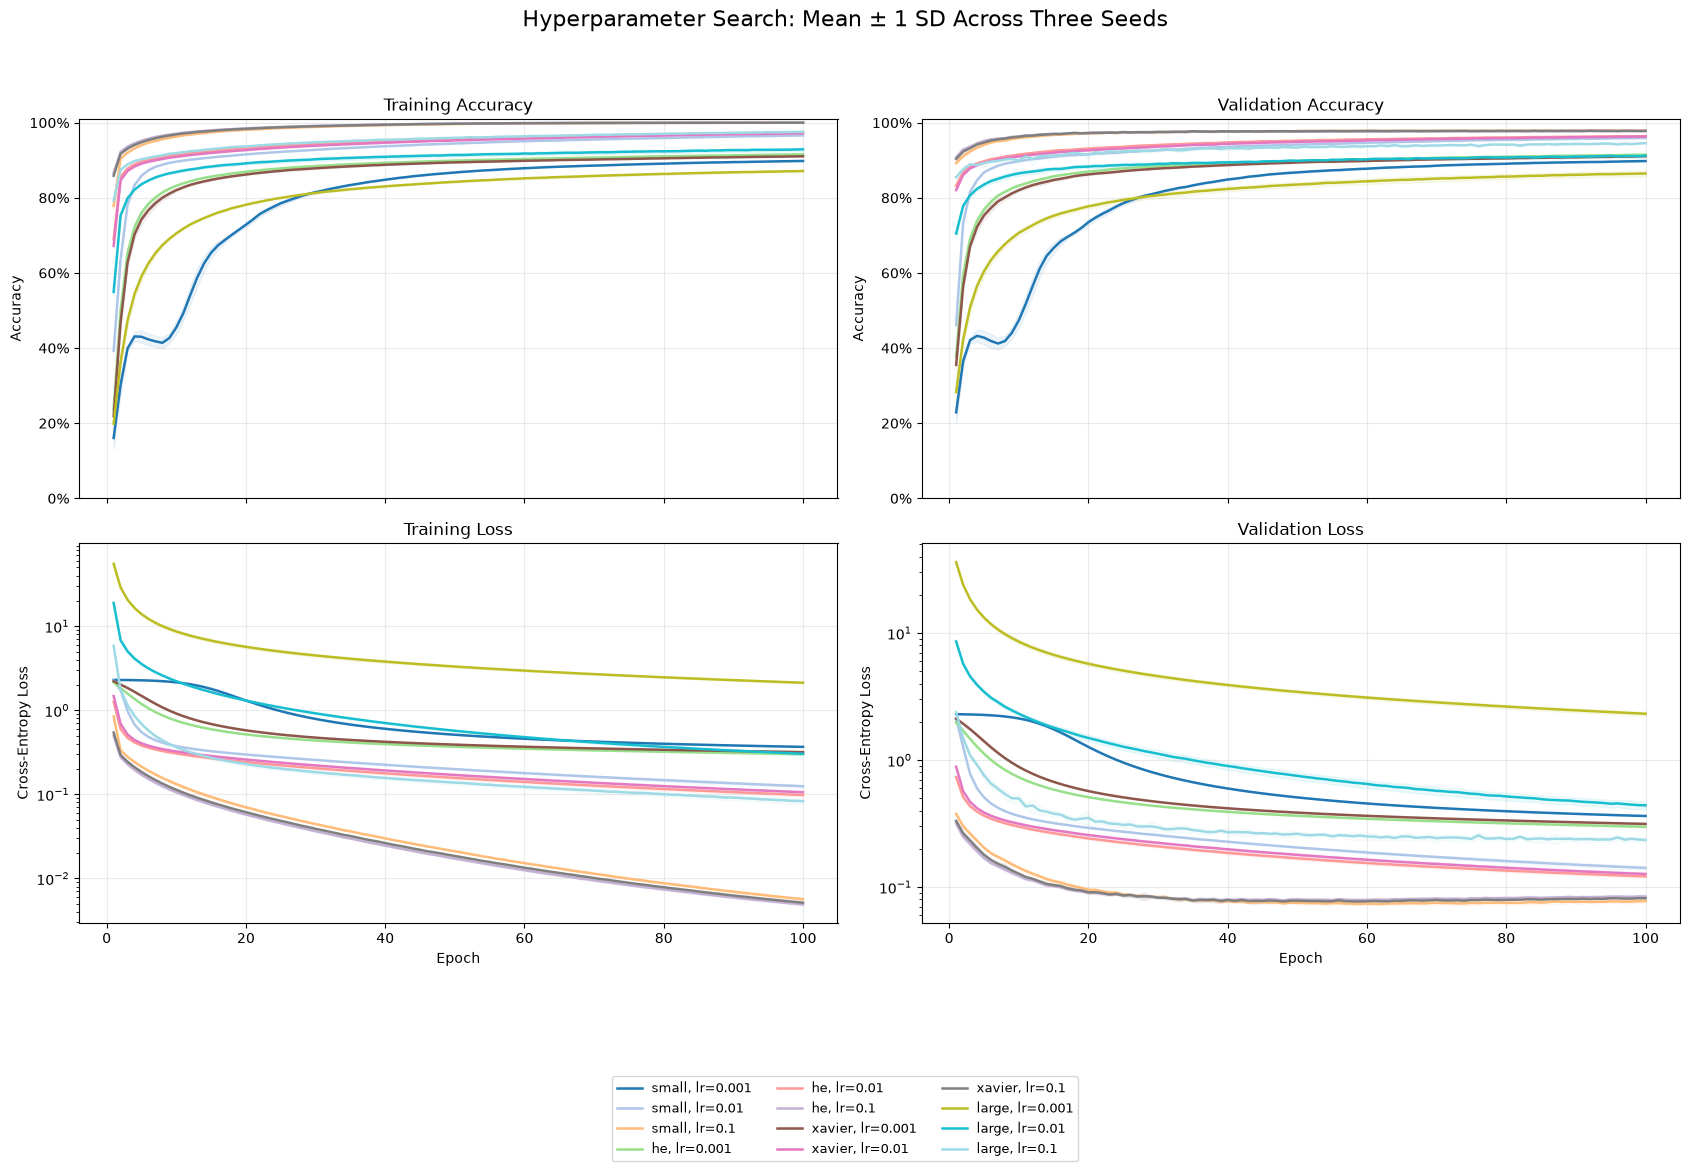

In [13]:
# ============================================================
# Plot mean ± 1 SD for every hyperparameter configuration
# ============================================================

configuration_order = []

for initialization in FINAL_INITIALIZATIONS:
    for learning_rate in FINAL_LEARNING_RATES:
        configuration_order.append(
            (
                initialization,
                float(learning_rate)
            )
        )


number_of_configurations = len(
    configuration_order
)


color_map = plt.get_cmap(
    "tab20"
)


configuration_colors = {
    configuration_key: color_map(
        color_index
        / max(
            number_of_configurations - 1,
            1
        )
    )
    for color_index, configuration_key
    in enumerate(configuration_order)
}


fig, axes = plt.subplots(
    2,
    2,
    figsize=(17, 12),
    sharex=True
)


for (
    initialization,
    learning_rate
) in configuration_order:

    configuration_data = (
        final_grid_history_summary_df[
            (
                final_grid_history_summary_df[
                    "initialization"
                ]
                == initialization
            )
            &
            (
                np.isclose(
                    final_grid_history_summary_df[
                        "learning_rate"
                    ],
                    learning_rate
                )
            )
        ]
        .sort_values("epoch")
    )

    epochs = configuration_data[
        "epoch"
    ].to_numpy()

    label = (
        f"{initialization}, "
        f"lr={learning_rate:g}"
    )

    color = configuration_colors[
        (
            initialization,
            learning_rate
        )
    ]


    # --------------------------------------------------------
    # Training accuracy
    # --------------------------------------------------------

    train_accuracy_mean = (
        configuration_data[
            "train_accuracy_mean"
        ]
        .to_numpy()
    )

    train_accuracy_std = (
        configuration_data[
            "train_accuracy_std"
        ]
        .to_numpy()
    )

    axes[0, 0].plot(
        epochs,
        train_accuracy_mean,
        color=color,
        linewidth=1.8,
        label=label
    )

    axes[0, 0].fill_between(
        epochs,
        np.clip(
            train_accuracy_mean
            - train_accuracy_std,
            0,
            1
        ),
        np.clip(
            train_accuracy_mean
            + train_accuracy_std,
            0,
            1
        ),
        color=color,
        alpha=0.08
    )


    # --------------------------------------------------------
    # Validation accuracy
    # --------------------------------------------------------

    validation_accuracy_mean = (
        configuration_data[
            "validation_accuracy_mean"
        ]
        .to_numpy()
    )

    validation_accuracy_std = (
        configuration_data[
            "validation_accuracy_std"
        ]
        .to_numpy()
    )

    axes[0, 1].plot(
        epochs,
        validation_accuracy_mean,
        color=color,
        linewidth=1.8
    )

    axes[0, 1].fill_between(
        epochs,
        np.clip(
            validation_accuracy_mean
            - validation_accuracy_std,
            0,
            1
        ),
        np.clip(
            validation_accuracy_mean
            + validation_accuracy_std,
            0,
            1
        ),
        color=color,
        alpha=0.08
    )


    # --------------------------------------------------------
    # Training loss
    # --------------------------------------------------------

    train_loss_mean = (
        configuration_data[
            "train_loss_mean"
        ]
        .to_numpy()
    )

    train_loss_std = (
        configuration_data[
            "train_loss_std"
        ]
        .to_numpy()
    )

    axes[1, 0].plot(
        epochs,
        train_loss_mean,
        color=color,
        linewidth=1.8
    )

    axes[1, 0].fill_between(
        epochs,
        np.maximum(
            train_loss_mean
            - train_loss_std,
            1e-12
        ),
        train_loss_mean
        + train_loss_std,
        color=color,
        alpha=0.08
    )


    # --------------------------------------------------------
    # Validation loss
    # --------------------------------------------------------

    validation_loss_mean = (
        configuration_data[
            "validation_loss_mean"
        ]
        .to_numpy()
    )

    validation_loss_std = (
        configuration_data[
            "validation_loss_std"
        ]
        .to_numpy()
    )

    axes[1, 1].plot(
        epochs,
        validation_loss_mean,
        color=color,
        linewidth=1.8
    )

    axes[1, 1].fill_between(
        epochs,
        np.maximum(
            validation_loss_mean
            - validation_loss_std,
            1e-12
        ),
        validation_loss_mean
        + validation_loss_std,
        color=color,
        alpha=0.08
    )


axes[0, 0].set_title(
    "Training Accuracy"
)

axes[0, 1].set_title(
    "Validation Accuracy"
)

axes[1, 0].set_title(
    "Training Loss"
)

axes[1, 1].set_title(
    "Validation Loss"
)


axes[0, 0].set_ylabel(
    "Accuracy"
)

axes[0, 1].set_ylabel(
    "Accuracy"
)

axes[1, 0].set_ylabel(
    "Cross-Entropy Loss"
)

axes[1, 1].set_ylabel(
    "Cross-Entropy Loss"
)


axes[1, 0].set_xlabel(
    "Epoch"
)

axes[1, 1].set_xlabel(
    "Epoch"
)


axes[0, 0].set_ylim(
    0,
    1.01
)

axes[0, 1].set_ylim(
    0,
    1.01
)


axes[0, 0].yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

axes[0, 1].yaxis.set_major_formatter(
    PercentFormatter(1.0)
)


# A logarithmic scale prevents high-loss configurations
# from hiding the better configurations.
axes[1, 0].set_yscale(
    "log"
)

axes[1, 1].set_yscale(
    "log"
)


for axis in axes.ravel():
    axis.grid(
        alpha=0.25
    )


fig.suptitle(
    "Hyperparameter Search: "
    "Mean ± 1 SD Across Three Seeds",
    fontsize=16
)


legend_handles, legend_labels = (
    axes[0, 0].get_legend_handles_labels()
)


# Shared legend underneath the x-axis
fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        0.015
    ),
    ncol=3,
    fontsize=9,
    frameon=True
)


plt.tight_layout(
    rect=[
        0,
        0.17,
        1,
        0.95
    ]
)


hyperparameter_curve_path = (
    FINAL_OUTPUT_DIR
    / "hyperparameter_training_validation_curves.png"
)


fig.savefig(
    hyperparameter_curve_path,
    dpi=300,
    bbox_inches="tight"
)


print(
    "Saved:",
    hyperparameter_curve_path
)


plt.show()
plt.close(fig)

In [14]:
# ============================================================
# Combine every training history into one DataFrame
# ============================================================

final_grid_history_rows = []


for (
    initialization,
    learning_rate,
    seed
), history in final_grid_histories.items():

    configuration_label = (
        f"{initialization}, "
        f"lr={learning_rate:g}"
    )

    number_of_epochs = len(
        history["train_loss"]
    )

    for epoch_index in range(
        number_of_epochs
    ):

        final_grid_history_rows.append({
            "configuration": configuration_label,
            "initialization": initialization,
            "learning_rate": learning_rate,
            "seed": seed,
            "epoch": epoch_index + 1,
            "train_loss": history[
                "train_loss"
            ][epoch_index],
            "train_accuracy": history[
                "train_accuracy"
            ][epoch_index],
            "validation_loss": history[
                "val_loss"
            ][epoch_index],
            "validation_accuracy": history[
                "val_accuracy"
            ][epoch_index],
            "selected_epoch": history[
                "best_epoch"
            ]
        })


final_grid_history_df = pd.DataFrame(
    final_grid_history_rows
)


final_grid_history_summary_df = (
    final_grid_history_df
    .groupby(
        [
            "configuration",
            "initialization",
            "learning_rate",
            "epoch"
        ],
        as_index=False
    )
    .agg(
        train_loss_mean=(
            "train_loss",
            "mean"
        ),
        train_loss_std=(
            "train_loss",
            "std"
        ),
        train_accuracy_mean=(
            "train_accuracy",
            "mean"
        ),
        train_accuracy_std=(
            "train_accuracy",
            "std"
        ),
        validation_loss_mean=(
            "validation_loss",
            "mean"
        ),
        validation_loss_std=(
            "validation_loss",
            "std"
        ),
        validation_accuracy_mean=(
            "validation_accuracy",
            "mean"
        ),
        validation_accuracy_std=(
            "validation_accuracy",
            "std"
        )
    )
)


# With three seeds, these values should already be finite.
# Filling missing values makes the plotting code robust.
standard_deviation_columns = [
    "train_loss_std",
    "train_accuracy_std",
    "validation_loss_std",
    "validation_accuracy_std"
]


final_grid_history_summary_df[
    standard_deviation_columns
] = (
    final_grid_history_summary_df[
        standard_deviation_columns
    ]
    .fillna(0.0)
)


all_history_path = (
    FINAL_OUTPUT_DIR
    / "hyperparameter_training_histories.csv"
)


history_summary_path = (
    FINAL_OUTPUT_DIR
    / "hyperparameter_curves_mean_std.csv"
)


final_grid_history_df.to_csv(
    all_history_path,
    index=False
)


final_grid_history_summary_df.to_csv(
    history_summary_path,
    index=False
)


print("Saved:", all_history_path)
print("Saved:", history_summary_path)

Saved: output/test_reports/hyperparameter_training_histories.csv
Saved: output/test_reports/hyperparameter_curves_mean_std.csv


Saved: output/test_reports/hyperparameter_training_validation_curves.png


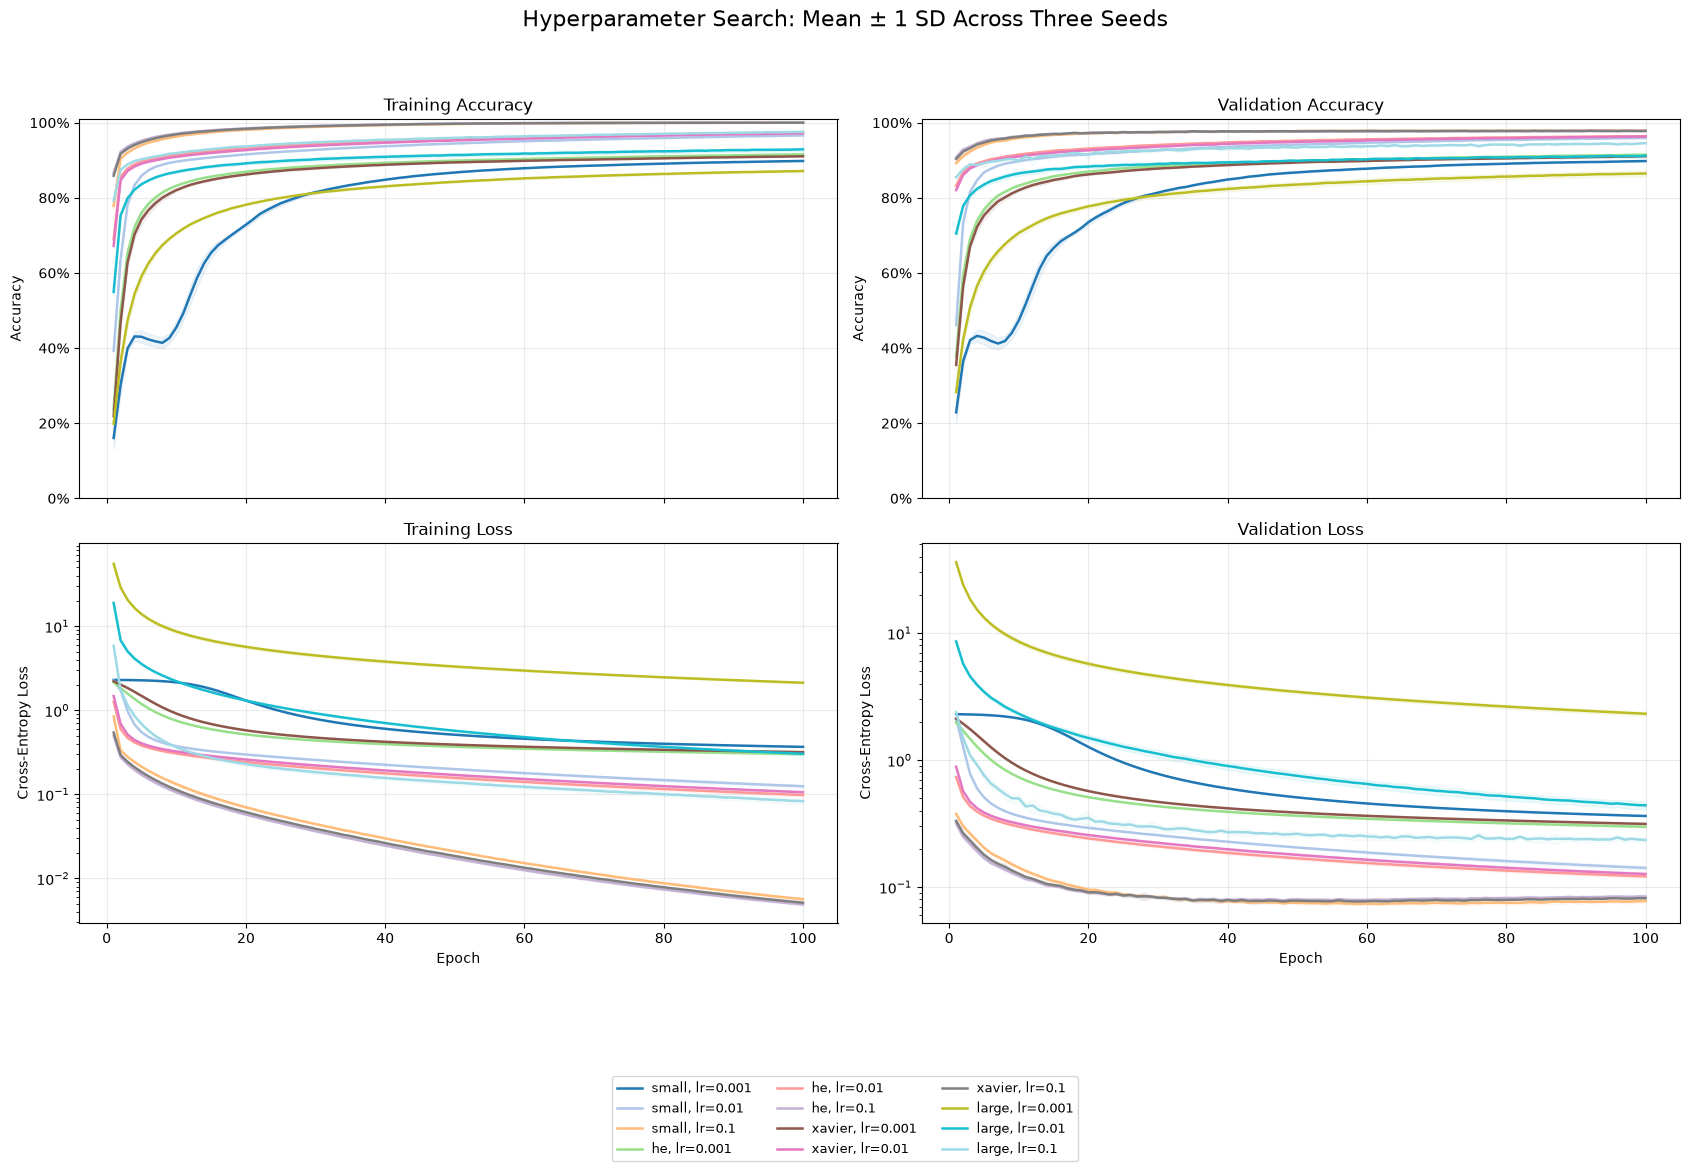

In [15]:
# ============================================================
# Plot mean ± 1 SD for every hyperparameter configuration
# ============================================================

configuration_order = []

for initialization in FINAL_INITIALIZATIONS:
    for learning_rate in FINAL_LEARNING_RATES:
        configuration_order.append(
            (
                initialization,
                float(learning_rate)
            )
        )


number_of_configurations = len(
    configuration_order
)


color_map = plt.get_cmap(
    "tab20"
)


configuration_colors = {
    configuration_key: color_map(
        color_index
        / max(
            number_of_configurations - 1,
            1
        )
    )
    for color_index, configuration_key
    in enumerate(configuration_order)
}


fig, axes = plt.subplots(
    2,
    2,
    figsize=(17, 12),
    sharex=True
)


for (
    initialization,
    learning_rate
) in configuration_order:

    configuration_data = (
        final_grid_history_summary_df[
            (
                final_grid_history_summary_df[
                    "initialization"
                ]
                == initialization
            )
            &
            (
                np.isclose(
                    final_grid_history_summary_df[
                        "learning_rate"
                    ],
                    learning_rate
                )
            )
        ]
        .sort_values("epoch")
    )

    epochs = configuration_data[
        "epoch"
    ].to_numpy()

    label = (
        f"{initialization}, "
        f"lr={learning_rate:g}"
    )

    color = configuration_colors[
        (
            initialization,
            learning_rate
        )
    ]


    # --------------------------------------------------------
    # Training accuracy
    # --------------------------------------------------------

    train_accuracy_mean = (
        configuration_data[
            "train_accuracy_mean"
        ]
        .to_numpy()
    )

    train_accuracy_std = (
        configuration_data[
            "train_accuracy_std"
        ]
        .to_numpy()
    )

    axes[0, 0].plot(
        epochs,
        train_accuracy_mean,
        color=color,
        linewidth=1.8,
        label=label
    )

    axes[0, 0].fill_between(
        epochs,
        np.clip(
            train_accuracy_mean
            - train_accuracy_std,
            0,
            1
        ),
        np.clip(
            train_accuracy_mean
            + train_accuracy_std,
            0,
            1
        ),
        color=color,
        alpha=0.08
    )


    # --------------------------------------------------------
    # Validation accuracy
    # --------------------------------------------------------

    validation_accuracy_mean = (
        configuration_data[
            "validation_accuracy_mean"
        ]
        .to_numpy()
    )

    validation_accuracy_std = (
        configuration_data[
            "validation_accuracy_std"
        ]
        .to_numpy()
    )

    axes[0, 1].plot(
        epochs,
        validation_accuracy_mean,
        color=color,
        linewidth=1.8
    )

    axes[0, 1].fill_between(
        epochs,
        np.clip(
            validation_accuracy_mean
            - validation_accuracy_std,
            0,
            1
        ),
        np.clip(
            validation_accuracy_mean
            + validation_accuracy_std,
            0,
            1
        ),
        color=color,
        alpha=0.08
    )


    # --------------------------------------------------------
    # Training loss
    # --------------------------------------------------------

    train_loss_mean = (
        configuration_data[
            "train_loss_mean"
        ]
        .to_numpy()
    )

    train_loss_std = (
        configuration_data[
            "train_loss_std"
        ]
        .to_numpy()
    )

    axes[1, 0].plot(
        epochs,
        train_loss_mean,
        color=color,
        linewidth=1.8
    )

    axes[1, 0].fill_between(
        epochs,
        np.maximum(
            train_loss_mean
            - train_loss_std,
            1e-12
        ),
        train_loss_mean
        + train_loss_std,
        color=color,
        alpha=0.08
    )


    # --------------------------------------------------------
    # Validation loss
    # --------------------------------------------------------

    validation_loss_mean = (
        configuration_data[
            "validation_loss_mean"
        ]
        .to_numpy()
    )

    validation_loss_std = (
        configuration_data[
            "validation_loss_std"
        ]
        .to_numpy()
    )

    axes[1, 1].plot(
        epochs,
        validation_loss_mean,
        color=color,
        linewidth=1.8
    )

    axes[1, 1].fill_between(
        epochs,
        np.maximum(
            validation_loss_mean
            - validation_loss_std,
            1e-12
        ),
        validation_loss_mean
        + validation_loss_std,
        color=color,
        alpha=0.08
    )


axes[0, 0].set_title(
    "Training Accuracy"
)

axes[0, 1].set_title(
    "Validation Accuracy"
)

axes[1, 0].set_title(
    "Training Loss"
)

axes[1, 1].set_title(
    "Validation Loss"
)


axes[0, 0].set_ylabel(
    "Accuracy"
)

axes[0, 1].set_ylabel(
    "Accuracy"
)

axes[1, 0].set_ylabel(
    "Cross-Entropy Loss"
)

axes[1, 1].set_ylabel(
    "Cross-Entropy Loss"
)


axes[1, 0].set_xlabel(
    "Epoch"
)

axes[1, 1].set_xlabel(
    "Epoch"
)


axes[0, 0].set_ylim(
    0,
    1.01
)

axes[0, 1].set_ylim(
    0,
    1.01
)


axes[0, 0].yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

axes[0, 1].yaxis.set_major_formatter(
    PercentFormatter(1.0)
)


# A logarithmic scale prevents high-loss configurations
# from hiding the better configurations.
axes[1, 0].set_yscale(
    "log"
)

axes[1, 1].set_yscale(
    "log"
)


for axis in axes.ravel():
    axis.grid(
        alpha=0.25
    )


fig.suptitle(
    "Hyperparameter Search: "
    "Mean ± 1 SD Across Three Seeds",
    fontsize=16
)


legend_handles, legend_labels = (
    axes[0, 0].get_legend_handles_labels()
)


# Shared legend underneath the x-axis
fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        0.015
    ),
    ncol=3,
    fontsize=9,
    frameon=True
)


plt.tight_layout(
    rect=[
        0,
        0.17,
        1,
        0.95
    ]
)


hyperparameter_curve_path = (
    FINAL_OUTPUT_DIR
    / "hyperparameter_training_validation_curves.png"
)


fig.savefig(
    hyperparameter_curve_path,
    dpi=300,
    bbox_inches="tight"
)


print(
    "Saved:",
    hyperparameter_curve_path
)


plt.show()
plt.close(fig)

Saved: output/test_reports/hyperparameter_validation_selection.png


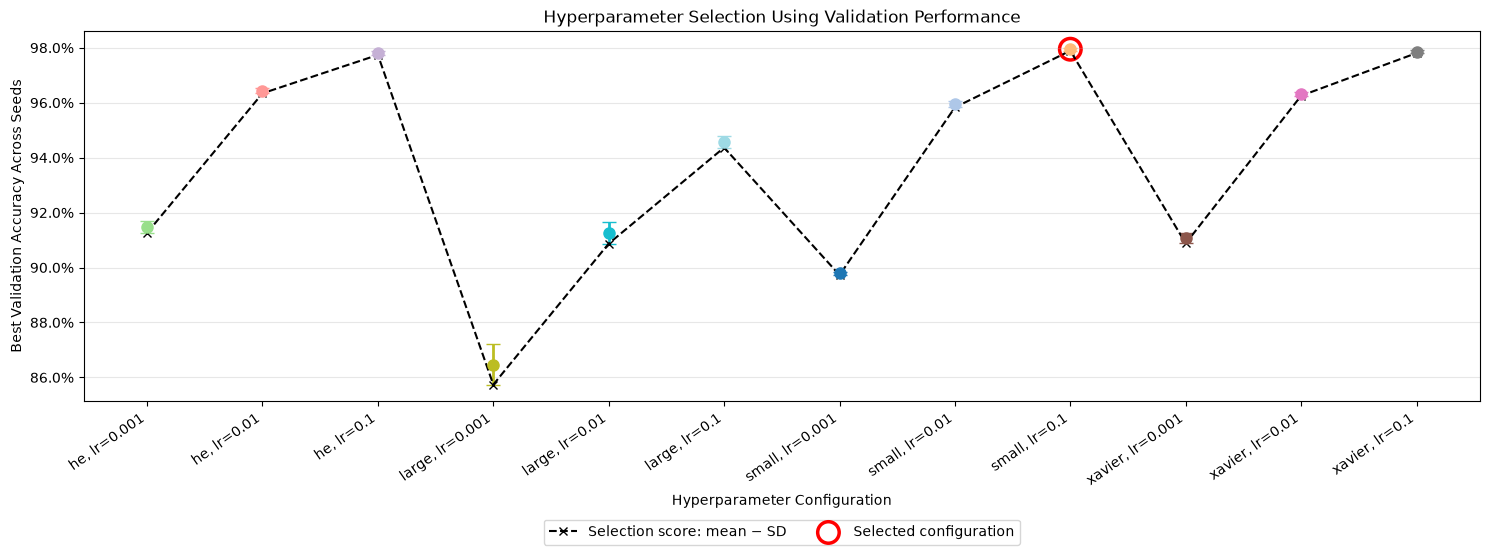

In [16]:
# ============================================================
# Validation performance used for model selection
# ============================================================

plot_configuration_df = (
    final_configuration_summary_df
    .sort_values(
        [
            "initialization",
            "learning_rate"
        ]
    )
    .reset_index(drop=True)
)


plot_labels = (
    plot_configuration_df[
        "configuration"
    ].tolist()
)


plot_means = (
    100
    * plot_configuration_df[
        "validation_accuracy_mean"
    ].to_numpy()
)


plot_stds = (
    100
    * plot_configuration_df[
        "validation_accuracy_std"
    ].to_numpy()
)


plot_scores = (
    100
    * plot_configuration_df[
        "selection_score"
    ].to_numpy()
)


plot_colors = [
    configuration_colors[
        (
            row["initialization"],
            float(row["learning_rate"])
        )
    ]
    for _, row
    in plot_configuration_df.iterrows()
]


x_positions = np.arange(
    len(plot_configuration_df)
)


fig, axis = plt.subplots(
    figsize=(15, 7)
)


for position in x_positions:

    axis.errorbar(
        position,
        plot_means[position],
        yerr=plot_stds[position],
        fmt="o",
        color=plot_colors[position],
        ecolor=plot_colors[position],
        markersize=8,
        capsize=5,
        linewidth=2
    )


axis.plot(
    x_positions,
    plot_scores,
    color="black",
    linestyle="--",
    marker="x",
    linewidth=1.5,
    label="Selection score: mean − SD"
)


selected_plot_position = int(
    np.argmax(plot_scores)
)


axis.scatter(
    selected_plot_position,
    plot_means[selected_plot_position],
    s=240,
    facecolors="none",
    edgecolors="red",
    linewidths=2.5,
    label="Selected configuration"
)


axis.set_xticks(
    x_positions
)

axis.set_xticklabels(
    plot_labels,
    rotation=35,
    ha="right"
)


axis.set_title(
    "Hyperparameter Selection Using Validation Performance"
)

axis.set_xlabel(
    "Hyperparameter Configuration"
)

axis.set_ylabel(
    "Best Validation Accuracy Across Seeds"
)


axis.yaxis.set_major_formatter(
    PercentFormatter(100)
)


axis.grid(
    axis="y",
    alpha=0.3
)


# Legend underneath the x-axis
axis.legend(
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.30
    ),
    ncol=2,
    frameon=True
)


plt.tight_layout(
    rect=[
        0,
        0.12,
        1,
        1
    ]
)


hyperparameter_selection_plot_path = (
    FINAL_OUTPUT_DIR
    / "hyperparameter_validation_selection.png"
)


fig.savefig(
    hyperparameter_selection_plot_path,
    dpi=300,
    bbox_inches="tight"
)


print(
    "Saved:",
    hyperparameter_selection_plot_path
)


plt.show()
plt.close(fig)

In [17]:
# ============================================================
# Verify the selected checkpoints before testing
# ============================================================

if len(selected_checkpoint_df) != len(FINAL_SEEDS):
    raise ValueError(
        "Expected one selected checkpoint for each seed. "
        f"Expected {len(FINAL_SEEDS)}, "
        f"found {len(selected_checkpoint_df)}."
    )


missing_checkpoint_paths = []


for checkpoint_path_string in (
    selected_checkpoint_df[
        "checkpoint_path"
    ]
):

    checkpoint_path = Path(
        checkpoint_path_string
    )

    if not checkpoint_path.exists():
        missing_checkpoint_paths.append(
            str(checkpoint_path)
        )


if missing_checkpoint_paths:
    raise FileNotFoundError(
        "The following selected checkpoints "
        "could not be found:\n"
        + "\n".join(
            missing_checkpoint_paths
        )
    )


print("Selected configuration is frozen.")
print(
    "Initialization:",
    SELECTED_INITIALIZATION
)
print(
    "Learning rate:",
    SELECTED_LEARNING_RATE
)
print(
    "Number of checkpoints:",
    len(selected_checkpoint_df)
)

print("\nThe following checkpoints will be tested:")

for checkpoint_path_string in (
    selected_checkpoint_df[
        "checkpoint_path"
    ]
):
    print(
        "-",
        checkpoint_path_string
    )

Selected configuration is frozen.
Initialization: small
Learning rate: 0.1
Number of checkpoints: 3

The following checkpoints will be tested:
- output/test_reports/checkpoints/best_model_init-small_lr-0p1_seed-89250.pt
- output/test_reports/checkpoints/best_model_init-small_lr-0p1_seed-654571.pt
- output/test_reports/checkpoints/best_model_init-small_lr-0p1_seed-773955.pt


In [18]:
# ============================================================
# FINAL TEST EVALUATION
#
# Run only after the hyperparameter configuration has been
# selected and frozen using validation data.
# ============================================================

final_test_rows = []


for _, selected_run in (
    selected_checkpoint_df.iterrows()
):

    checkpoint_path = Path(
        selected_run["checkpoint_path"]
    )


    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True
    )


    # --------------------------------------------------------
    # Confirm that this checkpoint belongs to the selected
    # hyperparameter configuration
    # --------------------------------------------------------

    if (
        checkpoint["initialization"]
        != SELECTED_INITIALIZATION
    ):
        raise ValueError(
            "Checkpoint initialization does not "
            "match the selected initialization."
        )


    if not np.isclose(
        checkpoint["learning_rate"],
        SELECTED_LEARNING_RATE
    ):
        raise ValueError(
            "Checkpoint learning rate does not "
            "match the selected learning rate."
        )


    # --------------------------------------------------------
    # Convert saved PyTorch tensors back to NumPy arrays.
    #
    # PyTorch is used only for saving/loading. The forward
    # pass and evaluation are still performed by the manual
    # NumPy implementation.
    # --------------------------------------------------------

    loaded_parameters = {
        parameter_name: (
            parameter_tensor
            .cpu()
            .numpy()
            .copy()
        )
        for (
            parameter_name,
            parameter_tensor
        ) in checkpoint[
            "parameters"
        ].items()
    }


    # --------------------------------------------------------
    # Evaluate this selected model on the test set
    # --------------------------------------------------------

    test_loss, test_accuracy = evaluate_model(
        X_test,
        y_test,
        loaded_parameters,
        checkpoint["activation"]
    )


    final_test_rows.append({
        "initialization": checkpoint[
            "initialization"
        ],
        "learning_rate": checkpoint[
            "learning_rate"
        ],
        "seed": checkpoint[
            "seed"
        ],
        "selected_epoch": checkpoint[
            "best_epoch"
        ],
        "validation_loss": checkpoint[
            "best_val_loss"
        ],
        "validation_accuracy": checkpoint[
            "best_val_accuracy"
        ],
        "test_loss": float(
            test_loss
        ),
        "test_accuracy": float(
            test_accuracy
        ),
        "checkpoint_path": str(
            checkpoint_path
        )
    })


    print(
        f"Seed {checkpoint['seed']} | "
        f"selected epoch="
        f"{checkpoint['best_epoch']} | "
        f"validation accuracy="
        f"{100 * checkpoint['best_val_accuracy']:.2f}% | "
        f"test loss={test_loss:.4f} | "
        f"test accuracy="
        f"{100 * test_accuracy:.2f}%"
    )


final_test_df = pd.DataFrame(
    final_test_rows
)


print(
    "\nFinished evaluating the three "
    "selected seed models."
)

Seed 89250 | selected epoch=68 | validation accuracy=97.95% | test loss=0.0716 | test accuracy=97.89%
Seed 654571 | selected epoch=75 | validation accuracy=98.00% | test loss=0.0716 | test accuracy=97.81%
Seed 773955 | selected epoch=80 | validation accuracy=97.89% | test loss=0.0719 | test accuracy=97.84%

Finished evaluating the three selected seed models.


In [19]:
# ============================================================
# Display test performance for each selected seed model
# ============================================================

final_test_display_df = pd.DataFrame({
    "Initialization": (
        final_test_df[
            "initialization"
        ]
    ),

    "Learning Rate": (
        final_test_df[
            "learning_rate"
        ]
    ),

    "Seed": (
        final_test_df[
            "seed"
        ]
    ),

    "Selected Epoch": (
        final_test_df[
            "selected_epoch"
        ]
    ),

    "Validation Loss": (
        final_test_df[
            "validation_loss"
        ]
        .map(
            lambda value: f"{value:.4f}"
        )
    ),

    "Validation Accuracy": (
        final_test_df[
            "validation_accuracy"
        ]
        .map(
            lambda value: (
                f"{100 * value:.2f}%"
            )
        )
    ),

    "Test Loss": (
        final_test_df[
            "test_loss"
        ]
        .map(
            lambda value: f"{value:.4f}"
        )
    ),

    "Test Accuracy": (
        final_test_df[
            "test_accuracy"
        ]
        .map(
            lambda value: (
                f"{100 * value:.2f}%"
            )
        )
    )
})


print(
    "Final test results for each seed"
)

display(
    final_test_display_df
)

Final test results for each seed


,Initialization,Learning Rate,Seed,Selected Epoch,Validation Loss,Validation Accuracy,Test Loss,Test Accuracy
0,small,0.1,89250,68,0.0759,97.95%,0.0716,97.89%
1,small,0.1,654571,75,0.0726,98.00%,0.0716,97.81%
2,small,0.1,773955,80,0.0743,97.89%,0.0719,97.84%


In [20]:
# ============================================================
# Final test mean and sample standard deviation
# ============================================================

test_loss_mean = (
    final_test_df[
        "test_loss"
    ].mean()
)

test_loss_std = (
    final_test_df[
        "test_loss"
    ].std(
        ddof=1
    )
)

test_accuracy_mean = (
    final_test_df[
        "test_accuracy"
    ].mean()
)

test_accuracy_std = (
    final_test_df[
        "test_accuracy"
    ].std(
        ddof=1
    )
)


validation_loss_mean = (
    final_test_df[
        "validation_loss"
    ].mean()
)

validation_loss_std = (
    final_test_df[
        "validation_loss"
    ].std(
        ddof=1
    )
)

validation_accuracy_mean = (
    final_test_df[
        "validation_accuracy"
    ].mean()
)

validation_accuracy_std = (
    final_test_df[
        "validation_accuracy"
    ].std(
        ddof=1
    )
)


final_performance_summary_df = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Test"
    ],

    "Loss Mean": [
        validation_loss_mean,
        test_loss_mean
    ],

    "Loss SD": [
        validation_loss_std,
        test_loss_std
    ],

    "Accuracy Mean": [
        validation_accuracy_mean,
        test_accuracy_mean
    ],

    "Accuracy SD": [
        validation_accuracy_std,
        test_accuracy_std
    ]
})


final_performance_display_df = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Test"
    ],

    "Loss": [
        (
            f"{validation_loss_mean:.4f} "
            f"± {validation_loss_std:.4f}"
        ),
        (
            f"{test_loss_mean:.4f} "
            f"± {test_loss_std:.4f}"
        )
    ],

    "Accuracy": [
        (
            f"{100 * validation_accuracy_mean:.2f}% "
            f"± "
            f"{100 * validation_accuracy_std:.2f}%"
        ),
        (
            f"{100 * test_accuracy_mean:.2f}% "
            f"± "
            f"{100 * test_accuracy_std:.2f}%"
        )
    ]
})


print("\n" + "=" * 75)
print("FINAL PERFORMANCE ACROSS THREE SEEDS")
print("=" * 75)

print(
    "Selected initialization:",
    SELECTED_INITIALIZATION
)

print(
    "Selected learning rate:",
    SELECTED_LEARNING_RATE
)

display(
    final_performance_display_df
)


print(
    "Final test accuracy: "
    f"{100 * test_accuracy_mean:.2f}% "
    f"± "
    f"{100 * test_accuracy_std:.2f}%"
)

print(
    "Final test loss: "
    f"{test_loss_mean:.4f} "
    f"± "
    f"{test_loss_std:.4f}"
)


FINAL PERFORMANCE ACROSS THREE SEEDS
Selected initialization: small
Selected learning rate: 0.1


,Dataset,Loss,Accuracy
0,Validation,0.0743 ± 0.0017,97.95% ± 0.06%
1,Test,0.0717 ± 0.0001,97.85% ± 0.04%


Final test accuracy: 97.85% ± 0.04%
Final test loss: 0.0717 ± 0.0001


Saved: output/test_reports/final_validation_test_accuracy.png


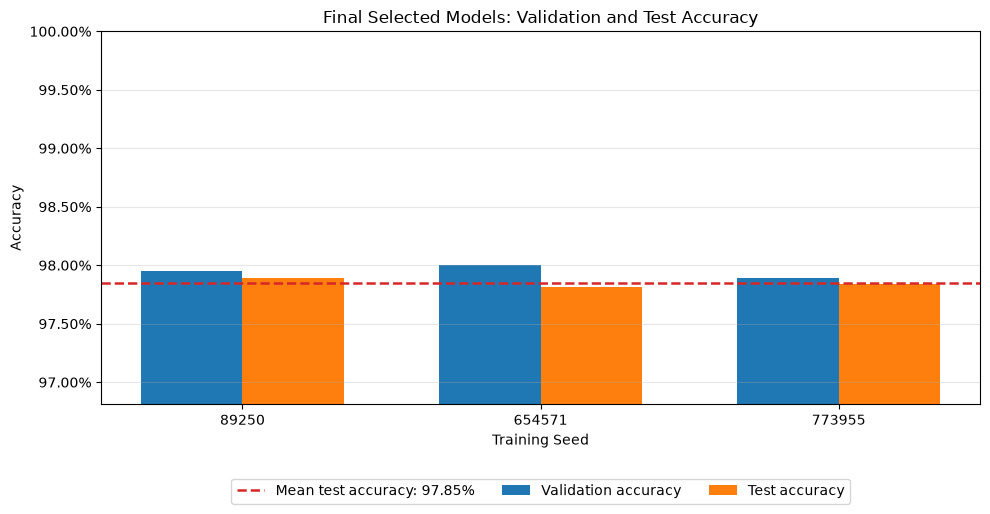

In [21]:
# ============================================================
# Plot validation and test accuracy for the selected models
# ============================================================

plot_seeds = (
    final_test_df[
        "seed"
    ]
    .astype(str)
    .tolist()
)


validation_accuracies = (
    100
    * final_test_df[
        "validation_accuracy"
    ].to_numpy()
)


test_accuracies = (
    100
    * final_test_df[
        "test_accuracy"
    ].to_numpy()
)


x_positions = np.arange(
    len(plot_seeds)
)


bar_width = 0.34


fig, axis = plt.subplots(
    figsize=(10, 6)
)


axis.bar(
    x_positions - bar_width / 2,
    validation_accuracies,
    width=bar_width,
    color="tab:blue",
    label="Validation accuracy"
)


axis.bar(
    x_positions + bar_width / 2,
    test_accuracies,
    width=bar_width,
    color="tab:orange",
    label="Test accuracy"
)


axis.axhline(
    100 * test_accuracy_mean,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
    label=(
        "Mean test accuracy: "
        f"{100 * test_accuracy_mean:.2f}%"
    )
)


axis.set_xticks(
    x_positions
)

axis.set_xticklabels(
    plot_seeds
)


axis.set_xlabel(
    "Training Seed"
)

axis.set_ylabel(
    "Accuracy"
)

axis.set_title(
    "Final Selected Models: "
    "Validation and Test Accuracy"
)


axis.yaxis.set_major_formatter(
    PercentFormatter(100)
)


minimum_accuracy = min(
    validation_accuracies.min(),
    test_accuracies.min()
)


axis.set_ylim(
    max(
        0,
        minimum_accuracy - 1.0
    ),
    100
)


axis.grid(
    axis="y",
    alpha=0.3
)


# Legend below the x-axis
axis.legend(
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.18
    ),
    ncol=3,
    frameon=True
)


plt.tight_layout(
    rect=[
        0,
        0.10,
        1,
        1
    ]
)


final_test_figure_path = (
    FINAL_OUTPUT_DIR
    / "final_validation_test_accuracy.png"
)


fig.savefig(
    final_test_figure_path,
    dpi=300,
    bbox_inches="tight"
)


print(
    "Saved:",
    final_test_figure_path
)


plt.show()
plt.close(fig)

In [22]:
# ============================================================
# Save final test results and summary
# ============================================================

final_test_results_path = (
    FINAL_OUTPUT_DIR
    / "final_test_results_by_seed.csv"
)

final_test_formatted_path = (
    FINAL_OUTPUT_DIR
    / "final_test_results_formatted.csv"
)

final_performance_summary_path = (
    FINAL_OUTPUT_DIR
    / "final_validation_test_summary.csv"
)


final_test_df.to_csv(
    final_test_results_path,
    index=False
)


final_test_display_df.to_csv(
    final_test_formatted_path,
    index=False
)


final_performance_summary_df.to_csv(
    final_performance_summary_path,
    index=False
)


print("Saved final result files:")
print("-", final_test_results_path)
print("-", final_test_formatted_path)
print("-", final_performance_summary_path)
print("-", final_test_figure_path)


print("\nAll files in the output directory:")

for file_path in sorted(
    FINAL_OUTPUT_DIR.iterdir()
):
    print("-", file_path)

Saved final result files:
- output/test_reports/final_test_results_by_seed.csv
- output/test_reports/final_test_results_formatted.csv
- output/test_reports/final_validation_test_summary.csv
- output/test_reports/final_validation_test_accuracy.png

All files in the output directory:
- output/test_reports/checkpoints
- output/test_reports/final_test_results_by_seed.csv
- output/test_reports/final_test_results_formatted.csv
- output/test_reports/final_validation_test_accuracy.png
- output/test_reports/final_validation_test_summary.csv
- output/test_reports/hyperparameter_configuration_summary.csv
- output/test_reports/hyperparameter_curves_mean_std.csv
- output/test_reports/hyperparameter_results_by_seed.csv
- output/test_reports/hyperparameter_training_histories.csv
- output/test_reports/hyperparameter_training_validation_curves.png
- output/test_reports/hyperparameter_validation_selection.png
- output/test_reports/selected_configuration_checkpoints.csv
- output/test_reports/selected_hyp